# 4.1 Diseño y desarrollo de un clasificador

## Propósito:
Aplicar los conocimientos teóricos y prácticos adquiridos durante el curso mediante el diseño y desarrollo de un clasificador sobre un tema de interés, buscando alcanzar una precisión superior al 92 %.

## Instrucciones:
Diseña, desarrolla e implementa un clasificador que permita resolver una problemática o atender una necesidad relacionada con el tema seleccionado. Documenta de manera clara el proceso realizado, desde el planteamiento del problema y la selección de los datos hasta la implementación, evaluación y análisis de los resultados.

## Características básicas:

- Definir claramente el problema y justificar la elección del tema.
- Presentar y describir los datos utilizados.
- Explicar el proceso de diseño y desarrollo del clasificador.
- Incluir el código fuente y describir su funcionamiento.
- Evaluar el desempeño del modelo, procurando una precisión superior al 92 %.
- Presentar y analizar los resultados obtenidos.
- Justificar la pertinencia y utilidad de la solución propuesta.


## 1. Planteamiento del problema y justificación

### 1.1 Problema

Los tumores cerebrales son de las neoplasias con mayor mortalidad y morbilidad. El diagnóstico se apoya principalmente en la **resonancia magnética (MRI)**, cuya interpretación requiere radiólogos y neurorradiólogos especializados. En muchos países, incluido México, estos especialistas se concentran en hospitales de tercer nivel, lo que retrasa el diagnóstico en regiones con pocos recursos. Además, distinguir visualmente el **tipo** de tumor (glioma, meningioma o adenoma hipofisario) es una tarea subjetiva, con variabilidad entre observadores.

El problema que se aborda es:

> Dada una imagen de resonancia magnética cerebral, clasificarla automáticamente en una de cuatro categorías: **glioma**, **meningioma**, **tumor pituitario** o **sin tumor**, con una exactitud superior al 92 %.

### 1.2 Justificación del tema

- **Relevancia clínica:** el tipo de tumor determina el tratamiento (cirugía, radioterapia, seguimiento) y el pronóstico. Un glioma de alto grado requiere atención urgente, mientras que muchos meningiomas son benignos.
- **Apoyo a la decisión:** un clasificador confiable puede funcionar como **segunda opinión** o como herramienta de **triaje**, priorizando los estudios sospechosos en la lista de trabajo del radiólogo.
- **Pertinencia con el curso:** el problema permite integrar los tres temas de la unidad:
  - **Transfer learning:** las redes preentrenadas en ImageNet aportan extractores de características robustos, útiles cuando el número de imágenes médicas es limitado.
  - **Redes generativas antagónicas (GAN):** una GAN condicional permite sintetizar imágenes adicionales por clase como estrategia de aumento de datos, algo muy relevante en medicina, donde los datos son escasos y costosos de etiquetar.
  - **Optimización de hiperparámetros:** la búsqueda bayesiana con Optuna permite encontrar sistemáticamente la mejor configuración de entrenamiento en lugar de ajustarla a mano.

## 2. Configuración del entorno

Se utiliza **PyTorch** con aceleración por GPU (NVIDIA RTX 4050, 6 GB), **torchvision** para el modelo preentrenado y las transformaciones, **Optuna** para la optimización de hiperparámetros y **scikit-learn** para las métricas.

La bandera `REENTRENAR` controla si los modelos se entrenan de nuevo o se cargan desde la carpeta `modelos/`. Así, el notebook puede volver a ejecutarse completo sin repetir los entrenamientos más costosos.

In [1]:
import os, time, json, random, copy, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, ConcatDataset
import torchvision
from torchvision import models
from torchvision.transforms import v2
from torchvision.utils import make_grid

import kagglehub
import optuna
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, roc_curve, auc)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
def fijar_semilla(s=SEED):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
fijar_semilla()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = True

BASE = Path.cwd()
DIR_DATOS, DIR_MODELOS, DIR_FIG = BASE / 'dataset', BASE / 'modelos', BASE / 'figuras'
for d in (DIR_DATOS, DIR_MODELOS, DIR_FIG):
    d.mkdir(exist_ok=True)

REENTRENAR = False  # True para volver a entrenar todo desde cero

print(f'PyTorch {torch.__version__} | torchvision {torchvision.__version__} | Optuna {optuna.__version__}')
print('Dispositivo:', device, '|', torch.cuda.get_device_name(0) if device.type == 'cuda' else 'CPU')

PyTorch 2.11.0+cu128 | torchvision 0.26.0+cu128 | Optuna 5.0.0
Dispositivo: cuda | NVIDIA GeForce RTX 4050 Laptop GPU


## 3. Datos

### 3.1 Descripción del dataset

Se utiliza el **Brain Tumor MRI Dataset** (Msoud Nickparvar, Kaggle), que combina imágenes de los conjuntos públicos *Figshare*, *SARTAJ* y *Br35H*. Contiene cortes 2D de resonancia magnética (en su mayoría secuencias T1 con contraste) en planos axial, coronal y sagital, organizados en cuatro clases:

| Clase | Descripción |
|:--|:--|
| **Glioma** | Tumor originado en las células gliales; suele ser infiltrante y de bordes difusos. |
| **Meningioma** | Tumor de las meninges; generalmente extra-axial, bien delimitado y benigno. |
| **Pituitario** | Adenoma de la glándula hipófisis, ubicado en la región selar. |
| **Sin tumor** | Cerebro sin lesión tumoral. |

El dataset trae una partición oficial en `Training` y `Testing`. El conjunto `Testing` **se reserva exclusivamente para la evaluación final**. Se descarga con `kagglehub`, que guarda una copia en caché local.

In [2]:
ruta_dataset = Path(kagglehub.dataset_download('masoudnickparvar/brain-tumor-mri-dataset'))
print('Ruta del dataset:', ruta_dataset)

CLASES = sorted(p.name for p in (ruta_dataset / 'Training').iterdir() if p.is_dir())
NOMBRES = {'glioma': 'Glioma', 'meningioma': 'Meningioma', 'notumor': 'Sin tumor', 'pituitary': 'Pituitario'}
ETIQUETAS = [NOMBRES[c] for c in CLASES]
N_CLASES = len(CLASES)

conteo = pd.DataFrame({split: {NOMBRES[c]: len(list((ruta_dataset / split / c).glob('*')))
                               for c in CLASES} for split in ('Training', 'Testing')})
conteo.loc['Total'] = conteo.sum()
conteo

Ruta del dataset: C:\Users\sebas\.cache\kagglehub\datasets\masoudnickparvar\brain-tumor-mri-dataset\versions\2


,Training,Testing
Glioma,1400,400
Meningioma,1400,400
Sin tumor,1400,400
Pituitario,1400,400
Total,5600,1600


### 3.2 Carga y preprocesamiento inicial

Las imágenes vienen en JPG con tamaños variables. Para acelerar el entrenamiento se cargan **una sola vez** en memoria con el siguiente preprocesamiento:

- **Escala de grises:** la resonancia magnética es monocanal, aunque algunos archivos vienen guardados en RGB.
- **Redimensionamiento a 256 x 256:** tamaño uniforme del que después se obtienen recortes de 224 x 224, la entrada estándar de los modelos preentrenados en ImageNet.

El resultado se guarda en `dataset/cache_256.pt` para no repetir la lectura de los archivos en ejecuciones posteriores.

In [3]:
TAM = 256

def cargar_split(split):
    imgs, etiquetas, tamanos = [], [], []
    for i, c in enumerate(CLASES):
        for f in sorted((ruta_dataset / split / c).iterdir()):
            with Image.open(f) as im:
                tamanos.append(im.size)
                imgs.append(np.asarray(im.convert('L').resize((TAM, TAM), Image.BILINEAR)))
            etiquetas.append(i)
    return torch.from_numpy(np.stack(imgs)).unsqueeze(1), torch.tensor(etiquetas), tamanos

ruta_cache = DIR_DATOS / f'cache_{TAM}.pt'
if ruta_cache.exists():
    datos = torch.load(ruta_cache)
else:
    t0 = time.time()
    X_tr, y_tr, tam_tr = cargar_split('Training')
    X_te, y_te, tam_te = cargar_split('Testing')
    datos = dict(X_train=X_tr, y_train=y_tr, X_test=X_te, y_test=y_te, tamanos=tam_tr + tam_te)
    torch.save(datos, ruta_cache)
    print(f'Imágenes cargadas en {time.time() - t0:.1f} s')

X_train_full, y_train_full = datos['X_train'], datos['y_train']
X_test, y_test = datos['X_test'], datos['y_test']
print('Entrenamiento:', tuple(X_train_full.shape), '| Prueba:', tuple(X_test.shape), '|', X_train_full.dtype)

Entrenamiento: (5600, 1, 256, 256) | Prueba: (1600, 1, 256, 256) | torch.uint8


### 3.3 Análisis exploratorio

Se revisa la distribución de clases, los tamaños originales de las imágenes y algunos ejemplos de cada categoría.

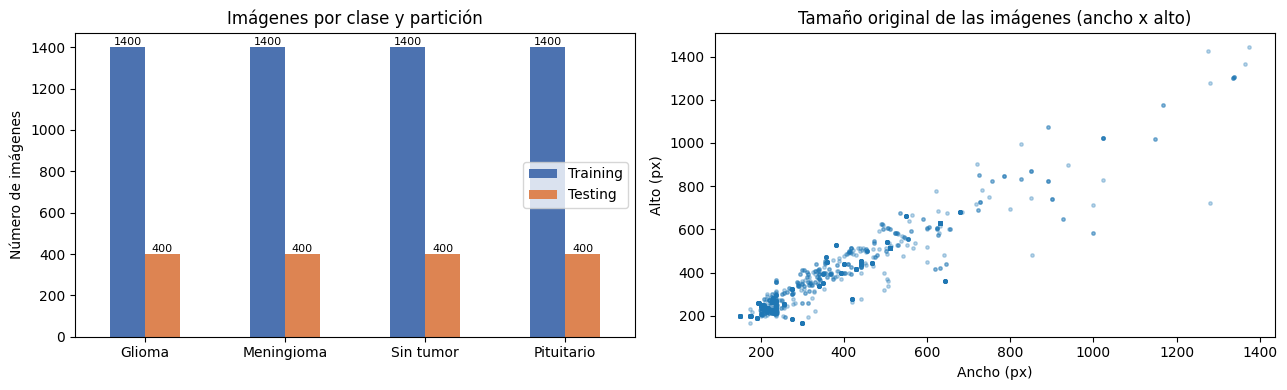

Ancho: min 150, mediana 512, max 1375
Alto:  min 167, mediana 512, max 1446


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
conteo.drop('Total').plot.bar(ax=ax[0], color=['#4C72B0', '#DD8452'], rot=0)
ax[0].set_title('Imágenes por clase y partición'); ax[0].set_ylabel('Número de imágenes')
for cont in ax[0].containers:
    ax[0].bar_label(cont, fontsize=8)

tamanos = np.array(datos['tamanos'])
ax[1].scatter(tamanos[:, 0], tamanos[:, 1], s=6, alpha=0.3)
ax[1].set_title('Tamaño original de las imágenes (ancho x alto)')
ax[1].set_xlabel('Ancho (px)'); ax[1].set_ylabel('Alto (px)')
plt.tight_layout(); plt.savefig(DIR_FIG / 'exploracion.png', dpi=120); plt.show()

anchos, altos = tamanos[:, 0], tamanos[:, 1]
print(f'Ancho: min {anchos.min()}, mediana {int(np.median(anchos))}, max {anchos.max()}')
print(f'Alto:  min {altos.min()}, mediana {int(np.median(altos))}, max {altos.max()}')

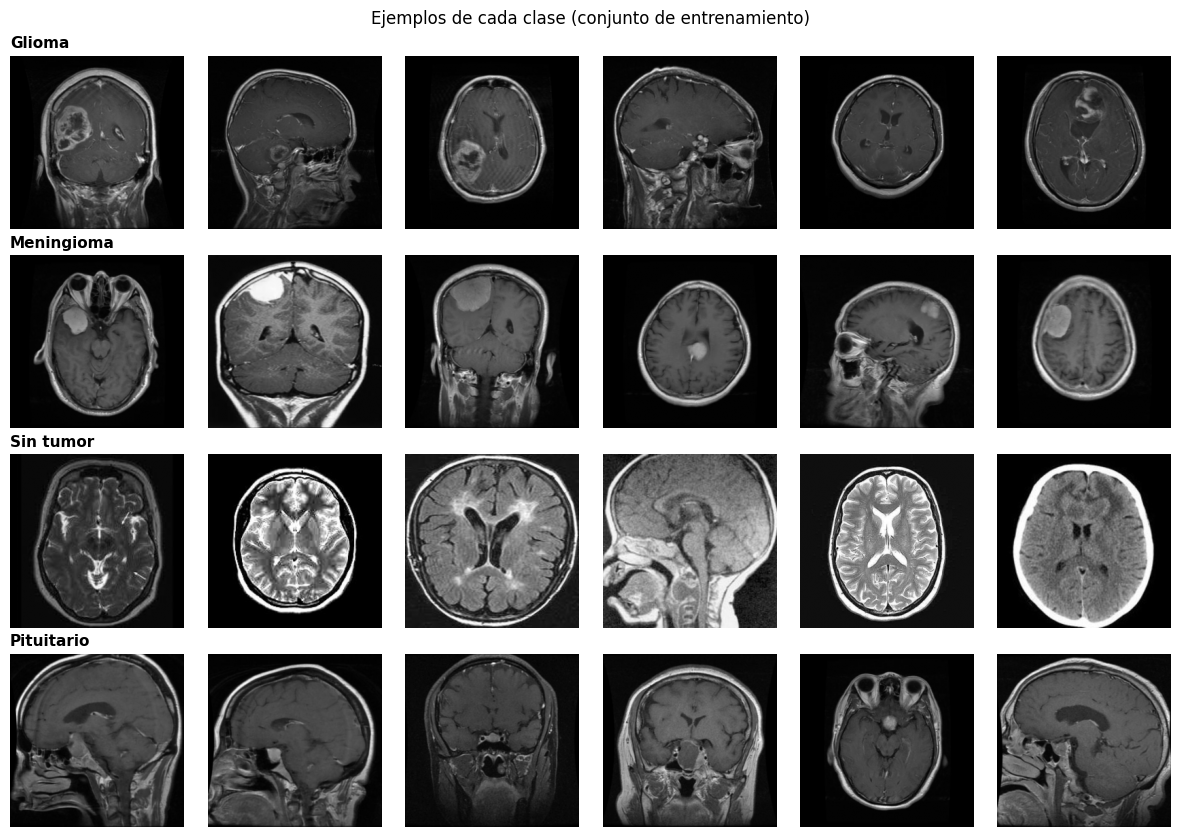

In [5]:
fig, axes = plt.subplots(N_CLASES, 6, figsize=(12, 8.5))
g = torch.Generator().manual_seed(SEED)
for i in range(N_CLASES):
    idx = torch.where(y_train_full == i)[0]
    sel = idx[torch.randperm(len(idx), generator=g)[:6]]
    for j, k in enumerate(sel):
        axes[i, j].imshow(X_train_full[k, 0], cmap='gray'); axes[i, j].axis('off')
    axes[i, 0].set_title(ETIQUETAS[i], loc='left', fontsize=11, fontweight='bold')
plt.suptitle('Ejemplos de cada clase (conjunto de entrenamiento)')
plt.tight_layout(); plt.savefig(DIR_FIG / 'ejemplos.png', dpi=120); plt.show()

**Observaciones:**

- El dataset está **perfectamente balanceado** (1,400 imágenes por clase en entrenamiento y 400 en prueba). Por eso la exactitud (*accuracy*) es una métrica adecuada y no se requiere ponderar clases.
- Los tamaños originales son muy variables, lo que justifica el redimensionamiento a un tamaño común.
- Hay imágenes en los tres planos anatómicos y con distintos contrastes, lo que hace la tarea más difícil que una simple detección de manchas: el modelo debe aprender la **ubicación** y la **morfología** de la lesión.

### 3.4 Particiones y aumento de datos

- **Entrenamiento (85 %)** y **validación (15 %)**: se obtienen de `Training` con muestreo estratificado. La validación se usa para el *early stopping*, la búsqueda de hiperparámetros y la selección del modelo.
- **Prueba:** el conjunto `Testing` oficial, que solo se usa al final.

Aumento de datos clásico, aplicado en línea y solo al entrenamiento:

- Recorte aleatorio con reescalado (`RandomResizedCrop`, 80-100 % del área) a 224 x 224.
- Volteo horizontal: el cerebro es aproximadamente simétrico y los tumores pueden aparecer en cualquier hemisferio.
- Rotación de ±10° y variaciones leves de brillo y contraste, que simulan diferencias de adquisición entre equipos.

Como los modelos preentrenados esperan 3 canales, la imagen en gris se replica en los tres canales y se normaliza con la media y desviación estándar de ImageNet.

In [6]:
idx_tr, idx_val = train_test_split(np.arange(len(y_train_full)), test_size=0.15,
                                   stratify=y_train_full.numpy(), random_state=SEED)
X_tr, y_tr = X_train_full[idx_tr], y_train_full[idx_tr]
X_val, y_val = X_train_full[idx_val], y_train_full[idx_val]

MEDIA, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

tf_train = v2.Compose([
    v2.RandomResizedCrop(224, scale=(0.8, 1.0), ratio=(0.9, 1.1), antialias=True),
    v2.RandomHorizontalFlip(),
    v2.RandomRotation(10),
    v2.ColorJitter(brightness=0.2, contrast=0.2),
    v2.ToDtype(torch.float32, scale=True),
])
tf_eval = v2.Compose([v2.Resize(224, antialias=True), v2.ToDtype(torch.float32, scale=True)])

class MRIDataset(Dataset):
    """Dataset en memoria: tensores uint8 (N, 1, 256, 256) y etiquetas enteras."""
    def __init__(self, X, y, transform):
        self.X, self.y, self.transform = X, y, transform
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        x = self.transform(self.X[i]).repeat(3, 1, 1)   # gris -> 3 canales
        return v2.functional.normalize(x, MEDIA, STD), self.y[i]

ds_train = MRIDataset(X_tr, y_tr, tf_train)
ds_val = MRIDataset(X_val, y_val, tf_eval)
ds_test = MRIDataset(X_test, y_test, tf_eval)
print(f'Entrenamiento: {len(ds_train)} | Validación: {len(ds_val)} | Prueba: {len(ds_test)}')

Entrenamiento: 4760 | Validación: 840 | Prueba: 1600


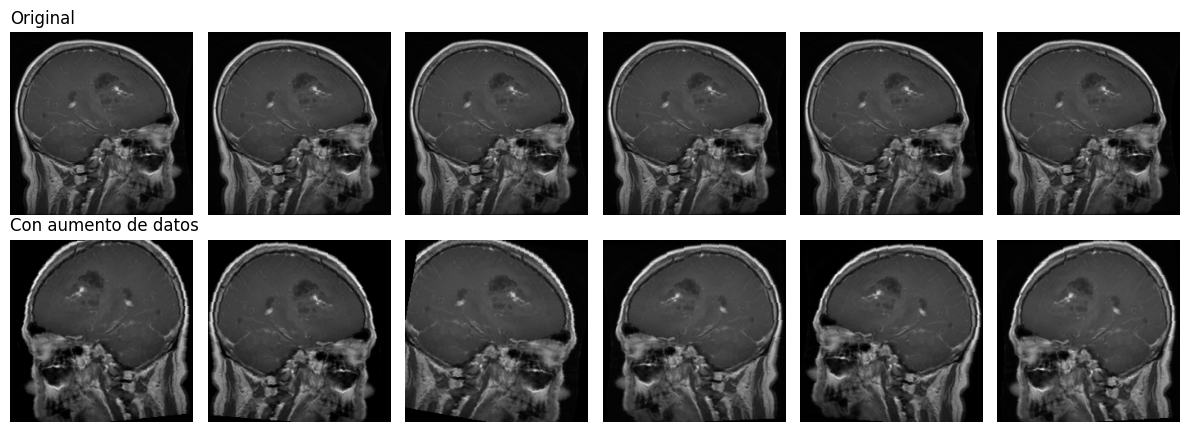

In [7]:
def desnormalizar(x):
    return (x[0] * STD[0] + MEDIA[0]).clamp(0, 1).numpy()

fig, axes = plt.subplots(2, 6, figsize=(12, 4.4))
for j in range(6):
    axes[0, j].imshow(X_tr[0, 0], cmap='gray'); axes[0, j].axis('off')
    axes[1, j].imshow(desnormalizar(ds_train[0][0]), cmap='gray'); axes[1, j].axis('off')
axes[0, 0].set_title('Original', loc='left'); axes[1, 0].set_title('Con aumento de datos', loc='left')
plt.tight_layout(); plt.show()

## 4. Red generativa antagónica condicional (cDCGAN)

### 4.1 Diseño

Para generar imágenes sintéticas **de una clase específica** se implementa una **DCGAN condicional** (Radford et al., 2015; Mirza y Osindero, 2014):

- **Generador G(z, y):** recibe un vector de ruido `z` de dimensión 100 concatenado con un *embedding* de la etiqueta `y` (dimensión 50). Mediante cinco convoluciones transpuestas con *BatchNorm* y ReLU lo transforma en una imagen de 64 x 64 en escala de grises, con activación `tanh` a la salida.
- **Discriminador D(x, y):** recibe la imagen y un mapa de la etiqueta (un *embedding* de 64 x 64 que se concatena como segundo canal). Mediante convoluciones con paso 2, *BatchNorm* y LeakyReLU produce un logit que indica si la imagen es real **y** corresponde a la clase indicada.

Detalles de entrenamiento siguiendo las recomendaciones de la DCGAN:

- Pérdida de entropía cruzada binaria (`BCEWithLogitsLoss`).
- Adam con lr = 2e-4 y β1 = 0.5.
- Pesos inicializados con N(0, 0.02).
- *Label smoothing* unilateral (etiqueta real = 0.9) para estabilizar al discriminador.
- Volteo horizontal aleatorio de las imágenes reales.

Se usa una resolución de 64 x 64 porque a resoluciones mayores el entrenamiento de una DCGAN se vuelve inestable y mucho más costoso. La GAN se entrena **solo con la partición de entrenamiento**, para que la validación no se contamine.

In [8]:
NZ, EMB = 100, 50

class Generador(nn.Module):
    def __init__(self, nz=NZ, n_clases=N_CLASES, emb=EMB, ngf=64):
        super().__init__()
        self.emb = nn.Embedding(n_clases, emb)
        def bloque(i, o, k=4, s=2, p=1):
            return [nn.ConvTranspose2d(i, o, k, s, p, bias=False), nn.BatchNorm2d(o), nn.ReLU(True)]
        self.red = nn.Sequential(
            *bloque(nz + emb, ngf * 8, 4, 1, 0),       # 4x4
            *bloque(ngf * 8, ngf * 4),                 # 8x8
            *bloque(ngf * 4, ngf * 2),                 # 16x16
            *bloque(ngf * 2, ngf),                     # 32x32
            nn.ConvTranspose2d(ngf, 1, 4, 2, 1), nn.Tanh())  # 64x64
    def forward(self, z, y):
        h = torch.cat([z, self.emb(y)], 1)[:, :, None, None]
        return self.red(h)

class Discriminador(nn.Module):
    def __init__(self, n_clases=N_CLASES, ndf=64):
        super().__init__()
        self.emb = nn.Embedding(n_clases, 64 * 64)
        def bloque(i, o, bn=True):
            capas = [nn.Conv2d(i, o, 4, 2, 1, bias=not bn)]
            if bn: capas.append(nn.BatchNorm2d(o))
            return capas + [nn.LeakyReLU(0.2, True)]
        self.red = nn.Sequential(
            *bloque(2, ndf, bn=False),      # 32x32
            *bloque(ndf, ndf * 2),          # 16x16
            *bloque(ndf * 2, ndf * 4),      # 8x8
            *bloque(ndf * 4, ndf * 8),      # 4x4
            nn.Conv2d(ndf * 8, 1, 4, 1, 0)) # logit
    def forward(self, x, y):
        mapa = self.emb(y).view(-1, 1, 64, 64)
        return self.red(torch.cat([x, mapa], 1)).view(-1)

def init_pesos(m):
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(m.weight, 0.0, 0.02)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.normal_(m.weight, 1.0, 0.02); nn.init.zeros_(m.bias)

G, D = Generador().to(device), Discriminador().to(device)
G.apply(init_pesos); D.apply(init_pesos)
print(f'Parámetros G: {sum(p.numel() for p in G.parameters()):,} | D: {sum(p.numel() for p in D.parameters()):,}')

Parámetros G: 3,984,457 | D: 2,780,993


### 4.2 Entrenamiento de la GAN

Las imágenes de entrenamiento se reducen a 64 x 64, se escalan a [-1, 1] y se cargan completas en la GPU, lo que hace muy rápido cada paso de entrenamiento. En cada iteración:

1. **Discriminador:** maximiza log D(x, y) + log(1 - D(G(z, y), y)) con imágenes reales y falsas de las mismas clases.
2. **Generador:** maximiza log D(G(z, y), y), la formulación no saturante.

Se guarda una grilla de muestras con ruido fijo cada cierto número de épocas para observar la evolución.

In [9]:
EPOCAS_GAN, LOTE_GAN = 150, 64
ruta_G = DIR_MODELOS / 'cdcgan_G.pt'
ruta_hist_gan = DIR_MODELOS / 'cdcgan_hist.json'

X64 = (F.interpolate(X_tr.float() / 255, size=64, mode='area') * 2 - 1).to(device)
y64 = y_tr.to(device)
z_fijo = torch.randn(N_CLASES * 8, NZ, device=device, generator=torch.Generator(device).manual_seed(SEED))
y_fijo = torch.arange(N_CLASES, device=device).repeat_interleave(8)

if ruta_G.exists() and not REENTRENAR:
    G.load_state_dict(torch.load(ruta_G)); hist_gan = json.load(open(ruta_hist_gan))
    print('Generador cargado desde', ruta_G.name)
else:
    fijar_semilla()
    opt_G = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
    opt_D = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
    bce = nn.BCEWithLogitsLoss()
    hist_gan = {'loss_D': [], 'loss_G': [], 'D_x': [], 'D_G_z': [], 'grillas': {}}
    n, t0 = len(X64), time.time()
    for ep in range(1, EPOCAS_GAN + 1):
        G.train(); D.train()
        perm = torch.randperm(n, device=device)
        lD = lG = dx = dgz = 0.0; pasos = 0
        for k in range(0, n - LOTE_GAN + 1, LOTE_GAN):
            idx = perm[k:k + LOTE_GAN]
            real, y = X64[idx], y64[idx]
            voltear = torch.rand(len(idx), device=device) < 0.5
            real = torch.where(voltear[:, None, None, None], real.flip(-1), real)
            z = torch.randn(len(idx), NZ, device=device)
            falsa = G(z, y)
            # Discriminador
            opt_D.zero_grad(set_to_none=True)
            out_real, out_falsa = D(real, y), D(falsa.detach(), y)
            loss_D = bce(out_real, torch.full_like(out_real, 0.9)) + bce(out_falsa, torch.zeros_like(out_falsa))
            loss_D.backward(); opt_D.step()
            # Generador
            opt_G.zero_grad(set_to_none=True)
            out = D(falsa, y)
            loss_G = bce(out, torch.ones_like(out))
            loss_G.backward(); opt_G.step()
            lD += loss_D.item(); lG += loss_G.item(); pasos += 1
            dx += torch.sigmoid(out_real).mean().item(); dgz += torch.sigmoid(out_falsa).mean().item()
        for clave, v in zip(('loss_D', 'loss_G', 'D_x', 'D_G_z'), (lD, lG, dx, dgz)):
            hist_gan[clave].append(v / pasos)
        if ep in (1, 10, 50, EPOCAS_GAN):
            G.eval()
            with torch.no_grad():
                hist_gan['grillas'][ep] = G(z_fijo, y_fijo).cpu().numpy().tolist()
        if ep % 15 == 0 or ep == 1:
            print(f'Época {ep:3d}/{EPOCAS_GAN} | loss_D {lD/pasos:.3f} | loss_G {lG/pasos:.3f} | '
                  f'D(x) {dx/pasos:.2f} | D(G(z)) {dgz/pasos:.2f} | {time.time()-t0:.0f} s')
    torch.save(G.state_dict(), ruta_G); json.dump(hist_gan, open(ruta_hist_gan, 'w'))
G.eval();

Generador cargado desde cdcgan_G.pt


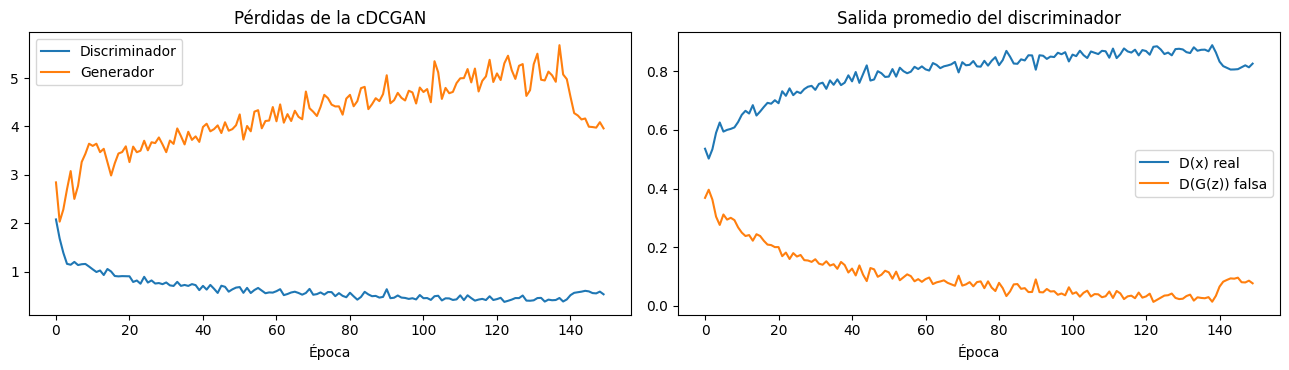

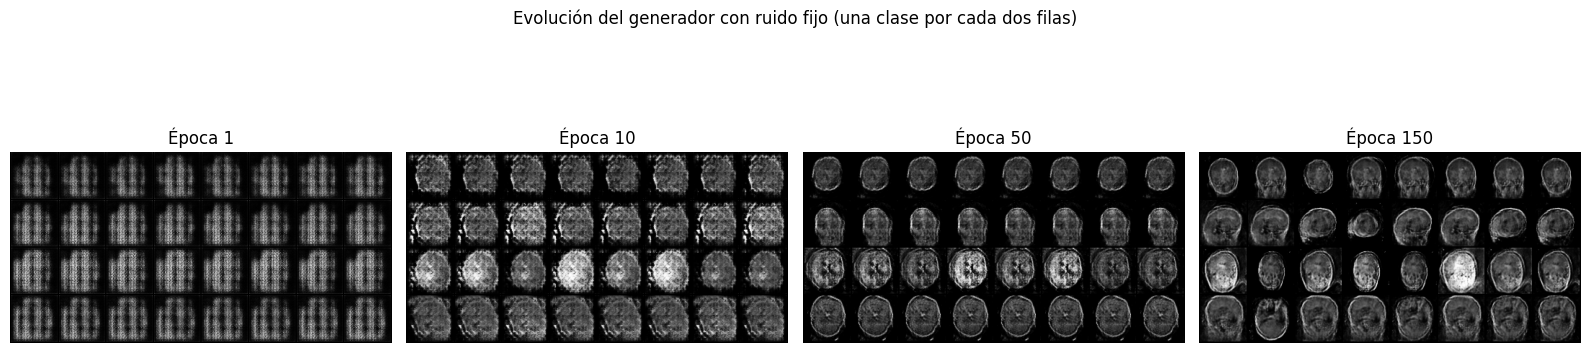

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
ax[0].plot(hist_gan['loss_D'], label='Discriminador'); ax[0].plot(hist_gan['loss_G'], label='Generador')
ax[0].set_title('Pérdidas de la cDCGAN'); ax[0].set_xlabel('Época'); ax[0].legend()
ax[1].plot(hist_gan['D_x'], label='D(x) real'); ax[1].plot(hist_gan['D_G_z'], label='D(G(z)) falsa')
ax[1].set_title('Salida promedio del discriminador'); ax[1].set_xlabel('Época'); ax[1].legend()
plt.tight_layout(); plt.savefig(DIR_FIG / 'gan_perdidas.png', dpi=120); plt.show()

epocas_g = sorted(hist_gan['grillas'], key=int)
fig, axes = plt.subplots(1, len(epocas_g), figsize=(4 * len(epocas_g), 4.6))
for a, ep in zip(axes, epocas_g):
    imgs = torch.tensor(hist_gan['grillas'][ep])
    a.imshow(make_grid(imgs, nrow=8, normalize=True, value_range=(-1, 1))[0], cmap='gray')
    a.set_title(f'Época {ep}'); a.axis('off')
plt.suptitle('Evolución del generador con ruido fijo (una clase por cada dos filas)')
plt.tight_layout(); plt.show()

### 4.3 Muestras sintéticas por clase

Se comparan imágenes reales (reducidas a 64 x 64) con imágenes generadas para cada clase.

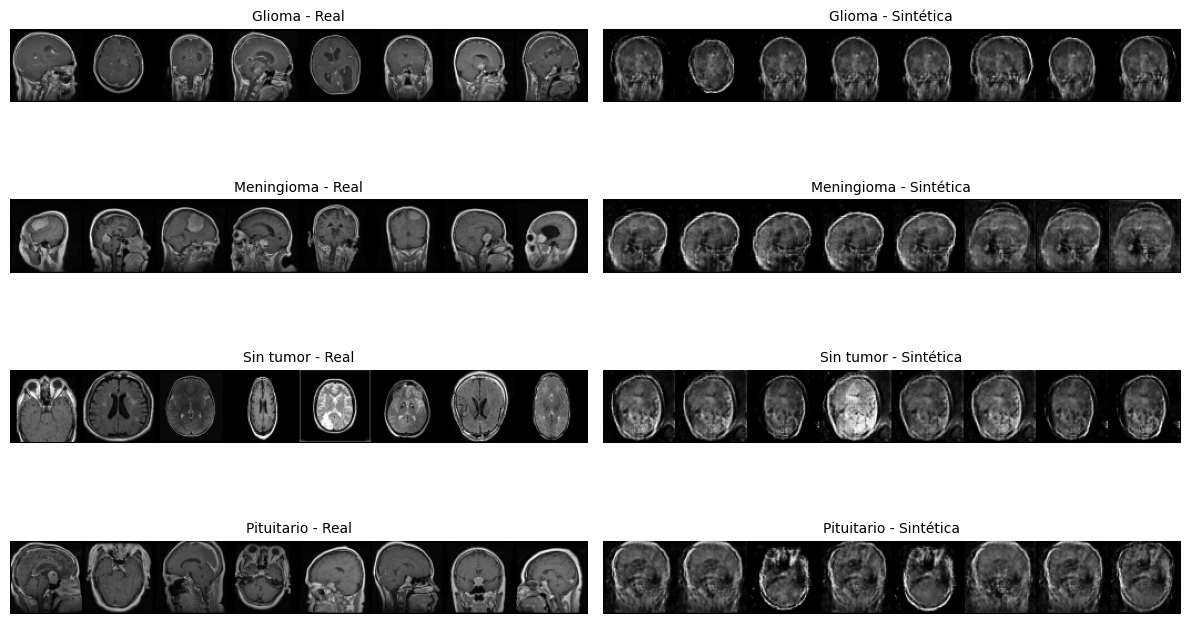

In [11]:
fig, axes = plt.subplots(N_CLASES, 2, figsize=(12, 7.5))
with torch.no_grad():
    for i in range(N_CLASES):
        reales = X64[y64 == i][:8].cpu()
        falsas = G(torch.randn(8, NZ, device=device), torch.full((8,), i, device=device)).cpu()
        for j, (imgs, tit) in enumerate(((reales, 'Real'), (falsas, 'Sintética'))):
            axes[i, j].imshow(make_grid(imgs, nrow=8, normalize=True, value_range=(-1, 1), padding=1)[0], cmap='gray')
            axes[i, j].set_title(f'{ETIQUETAS[i]} - {tit}', fontsize=10); axes[i, j].axis('off')
plt.tight_layout(); plt.savefig(DIR_FIG / 'gan_muestras.png', dpi=120); plt.show()

### 4.4 Generación del conjunto sintético

Se generan **300 imágenes por clase** (1,200 en total, cerca del 25 % del conjunto de entrenamiento real). Se reescalan a 256 x 256 para pasar por el mismo flujo de aumento de datos que las imágenes reales. Más adelante, la búsqueda de hiperparámetros decidirá, mediante la variable `usar_sinteticos`, si conviene incluirlas en el entrenamiento.

In [12]:
N_SINT = 300
gen = torch.Generator(device).manual_seed(SEED)
with torch.no_grad():
    y_sint = torch.arange(N_CLASES, device=device).repeat_interleave(N_SINT)
    z = torch.randn(len(y_sint), NZ, device=device, generator=gen)
    x = torch.cat([G(z[k:k + 400], y_sint[k:k + 400]) for k in range(0, len(z), 400)])
    x = F.interpolate((x + 1) / 2, size=TAM, mode='bilinear', align_corners=False)
    X_sint = (x.clamp(0, 1) * 255).round().to(torch.uint8).cpu()
y_sint = y_sint.cpu()
ds_sint = MRIDataset(X_sint, y_sint, tf_train)
ds_train_gan = ConcatDataset([ds_train, ds_sint])
print(f'Sintéticas: {len(ds_sint)} | Entrenamiento real + sintético: {len(ds_train_gan)}')
del X64; torch.cuda.empty_cache()

Sintéticas: 1200 | Entrenamiento real + sintético: 5960


## 5. Clasificador con transfer learning

### 5.1 Selección de la arquitectura

Se elige **EfficientNet-B0** preentrenada en ImageNet (Tan y Le, 2019) por las siguientes razones:

- Ofrece una excelente relación entre exactitud y costo (5.3 M de parámetros, 0.39 GFLOPs). Esto permite entrenar con 6 GB de VRAM y ejecutar decenas de pruebas de hiperparámetros.
- Sus bloques MBConv con *squeeze-and-excitation* han mostrado buen desempeño en imágenes médicas.
- Su extractor de características (`features`) está dividido en 9 bloques, lo que facilita controlar cuántos se descongelan durante el *fine-tuning*.

La cabeza original (1,000 clases) se reemplaza por `Dropout` seguido de `Linear(1280, 4)`.

### 5.2 Estrategias de transfer learning

1. **Extracción de características:** todo el backbone se congela y solo se entrena la cabeza. Las capas de *BatchNorm* congeladas se mantienen en modo evaluación para conservar las estadísticas de ImageNet.
2. **Fine-tuning:** se descongela total o parcialmente el backbone y se entrena con una tasa de aprendizaje menor, para adaptar los filtros al dominio de resonancia magnética.

### 5.3 Función de entrenamiento

La función `entrenar` es común a todos los experimentos e incluye:

- Precisión mixta (`torch.autocast` + `GradScaler`) para acelerar y reducir el uso de memoria.
- Política de tasa de aprendizaje *One-Cycle*: calentamiento seguido de decaimiento coseno.
- *Early stopping* sobre la exactitud de validación, restaurando los mejores pesos.
- Integración con Optuna: reporta la exactitud de cada época para que el *pruner* detenga pruebas poco prometedoras.

In [13]:
def crear_modelo(dropout=0.3):
    m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    m.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(m.classifier[1].in_features, N_CLASES))
    return m

def configurar_congelamiento(m, bloques):
    """Congela el backbone y descongela sus últimos `bloques` (0 = solo la cabeza, 9 = todo)."""
    for p in m.features.parameters():
        p.requires_grad = False
    if bloques > 0:
        for p in m.features[-bloques:].parameters():
            p.requires_grad = True

def modo_entrenamiento(m):
    m.train()
    for mod in m.features.modules():  # BatchNorm congelada se queda en modo evaluación
        if isinstance(mod, nn.BatchNorm2d) and not mod.weight.requires_grad:
            mod.eval()

@torch.no_grad()
def predecir(m, ds, lote=128):
    m.eval(); probs, ys = [], []
    for x, y in DataLoader(ds, batch_size=lote, num_workers=0):
        with torch.autocast(device.type, dtype=torch.float16):
            probs.append(F.softmax(m(x.to(device)).float(), 1).cpu())
        ys.append(y)
    return torch.cat(ys).numpy(), torch.cat(probs).numpy()

def entrenar(cfg, ds_tr, ds_va, epocas, paciencia=4, trial=None, verbose=True):
    fijar_semilla()
    m = crear_modelo(cfg['dropout']).to(device)
    configurar_congelamiento(m, cfg['bloques'])
    params = [p for p in m.parameters() if p.requires_grad]
    if cfg['optimizador'] == 'AdamW':
        opt = torch.optim.AdamW(params, lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    else:
        opt = torch.optim.SGD(params, lr=cfg['lr'], momentum=0.9, nesterov=True, weight_decay=cfg['weight_decay'])
    dl = DataLoader(ds_tr, batch_size=cfg['batch_size'], shuffle=True, num_workers=0, drop_last=True)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=cfg['lr'], total_steps=epocas * len(dl), pct_start=0.15)
    crit = nn.CrossEntropyLoss(label_smoothing=cfg['label_smoothing'])
    scaler = torch.amp.GradScaler()
    hist = {k: [] for k in ('loss', 'acc', 'val_loss', 'val_acc')}
    mejor_acc, mejor_estado, sin_mejora = -1, None, 0
    for ep in range(epocas):
        t0 = time.time(); modo_entrenamiento(m)
        suma_loss = aciertos = total = 0
        for x, y in dl:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.autocast(device.type, dtype=torch.float16):
                out = m(x); loss = crit(out, y)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); sched.step()
            suma_loss += loss.item() * len(y); aciertos += (out.argmax(1) == y).sum().item(); total += len(y)
        yv, pv = predecir(m, ds_va)
        val_acc = (pv.argmax(1) == yv).mean()
        val_loss = -np.log(pv[np.arange(len(yv)), yv] + 1e-8).mean()
        for k, v in zip(hist, (suma_loss / total, aciertos / total, val_loss, val_acc)):
            hist[k].append(float(v))
        if verbose:
            print(f'Época {ep+1:2d}/{epocas} | loss {suma_loss/total:.4f} | acc {aciertos/total:.4f} | '
                  f'val_loss {val_loss:.4f} | val_acc {val_acc:.4f} | {time.time()-t0:.0f} s')
        if trial is not None:
            trial.report(val_acc, ep)
            if trial.should_prune():
                raise optuna.TrialPruned()
        if val_acc > mejor_acc:
            mejor_acc, sin_mejora = val_acc, 0
            mejor_estado = {k: v.detach().cpu().clone() for k, v in m.state_dict().items()}
        else:
            sin_mejora += 1
            if sin_mejora >= paciencia:
                if verbose: print(f'Early stopping en la época {ep+1}')
                break
    m.load_state_dict(mejor_estado)
    return m, hist, float(mejor_acc)

def obtener_modelo(nombre, cfg, ds_tr, ds_va, epocas, **kw):
    """Entrena y guarda el modelo, o lo carga si ya existe (salvo REENTRENAR=True)."""
    ruta_pt, ruta_h = DIR_MODELOS / f'{nombre}.pt', DIR_MODELOS / f'{nombre}_hist.json'
    if ruta_pt.exists() and not REENTRENAR:
        m = crear_modelo(cfg['dropout']).to(device)
        m.load_state_dict(torch.load(ruta_pt)); hist = json.load(open(ruta_h))
        print(f'{nombre}: cargado desde disco ({len(hist["val_acc"])} épocas, mejor val_acc {max(hist["val_acc"]):.4f})')
    else:
        t0 = time.time()
        m, hist, _ = entrenar(cfg, ds_tr, ds_va, epocas, **kw)
        torch.save(m.state_dict(), ruta_pt); json.dump(hist, open(ruta_h, 'w'))
        print(f'{nombre}: entrenado en {(time.time()-t0)/60:.1f} min')
    return m, hist

def graficar_historial(hist, titulo):
    fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
    ep = range(1, len(hist['loss']) + 1)
    ax[0].plot(ep, hist['loss'], 'o-', label='Entrenamiento'); ax[0].plot(ep, hist['val_loss'], 'o-', label='Validación')
    ax[0].set_title(f'{titulo}: pérdida'); ax[0].set_xlabel('Época'); ax[0].legend()
    ax[1].plot(ep, hist['acc'], 'o-', label='Entrenamiento'); ax[1].plot(ep, hist['val_acc'], 'o-', label='Validación')
    ax[1].axhline(0.92, color='gray', ls='--', lw=1, label='Meta 92 %')
    ax[1].set_title(f'{titulo}: exactitud'); ax[1].set_xlabel('Época'); ax[1].legend()
    plt.tight_layout(); plt.show()

resultados = {}  # nombre -> modelo

### 5.4 Experimento A: extracción de características (backbone congelado)

Configuración base: AdamW con lr = 1e-3, *dropout* de 0.3, lotes de 32 y 8 épocas. Solo se entrenan los 5,124 parámetros de la cabeza.

A_extraccion_caracteristicas: cargado desde disco (8 épocas, mejor val_acc 0.9048)


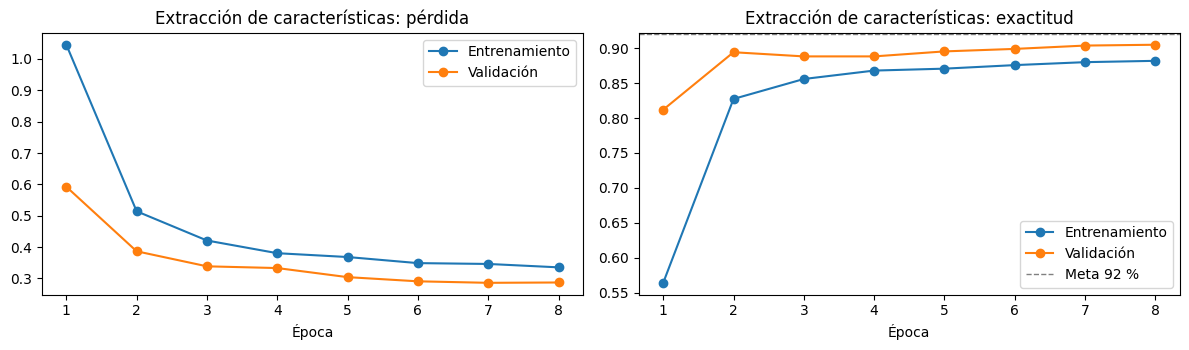

In [14]:
cfg_fe = dict(lr=1e-3, weight_decay=1e-4, dropout=0.3, optimizador='AdamW',
              batch_size=32, bloques=0, label_smoothing=0.0)
modelo_fe, hist_fe = obtener_modelo('A_extraccion_caracteristicas', cfg_fe, ds_train, ds_val, epocas=8)
resultados['A. Extracción de características'] = modelo_fe
graficar_historial(hist_fe, 'Extracción de características')

### 5.5 Experimento B: fine-tuning completo con hiperparámetros manuales

Se descongela todo el backbone (9 bloques) y se usa lr = 3e-4, un valor típico para *fine-tuning* con AdamW, durante 12 épocas.

Época  1/12 | loss 0.9243 | acc 0.6364 | val_loss 0.2920 | val_acc 0.8917 | 135 s
Época  2/12 | loss 0.2278 | acc 0.9242 | val_loss 0.0817 | val_acc 0.9726 | 25 s
Época  3/12 | loss 0.1165 | acc 0.9605 | val_loss 0.0466 | val_acc 0.9821 | 26 s
Época  4/12 | loss 0.0830 | acc 0.9723 | val_loss 0.1418 | val_acc 0.9429 | 26 s
Época  5/12 | loss 0.0436 | acc 0.9856 | val_loss 0.0210 | val_acc 0.9929 | 26 s
Época  6/12 | loss 0.0347 | acc 0.9894 | val_loss 0.0400 | val_acc 0.9881 | 27 s
Época  7/12 | loss 0.0265 | acc 0.9916 | val_loss 0.0279 | val_acc 0.9917 | 26 s
Época  8/12 | loss 0.0157 | acc 0.9951 | val_loss 0.0144 | val_acc 0.9929 | 26 s
Época  9/12 | loss 0.0124 | acc 0.9964 | val_loss 0.0208 | val_acc 0.9940 | 27 s
Época 10/12 | loss 0.0123 | acc 0.9960 | val_loss 0.0209 | val_acc 0.9952 | 26 s
Época 11/12 | loss 0.0095 | acc 0.9968 | val_loss 0.0192 | val_acc 0.9964 | 26 s
Época 12/12 | loss 0.0113 | acc 0.9960 | val_loss 0.0199 | val_acc 0.9952 | 26 s
B_fine_tuning_manual: entre

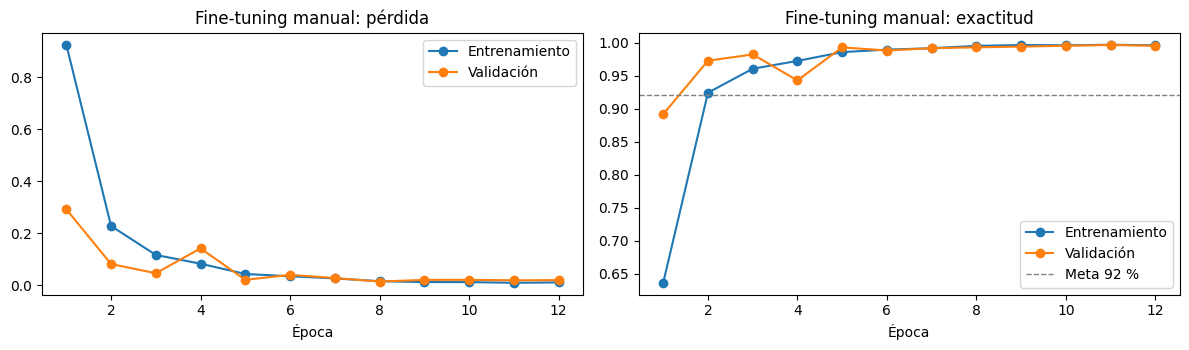

In [15]:
cfg_ft = dict(lr=3e-4, weight_decay=1e-4, dropout=0.3, optimizador='AdamW',
              batch_size=32, bloques=9, label_smoothing=0.0)
modelo_ft, hist_ft = obtener_modelo('B_fine_tuning_manual', cfg_ft, ds_train, ds_val, epocas=12)
resultados['B. Fine-tuning manual'] = modelo_ft
graficar_historial(hist_ft, 'Fine-tuning manual')

## 6. Optimización de hiperparámetros con Optuna

### 6.1 Planteamiento

En lugar de fijar los hiperparámetros a mano, se plantea su elección como un problema de optimización: **maximizar la exactitud de validación**. Se usa Optuna con:

- **Muestreador TPE** (*Tree-structured Parzen Estimator*): búsqueda bayesiana que modela qué regiones del espacio producen buenos resultados y concentra ahí las siguientes pruebas. Es más eficiente que la búsqueda en malla o aleatoria.
- ***MedianPruner***: detiene una prueba si, en la misma época, su exactitud queda por debajo de la mediana de las pruebas anteriores. Así se ahorra tiempo de GPU en configuraciones malas.

Espacio de búsqueda:

| Hiperparámetro | Rango / opciones | Rol |
|:--|:--|:--|
| `lr` | 5e-5 a 3e-3 (log) | Tasa de aprendizaje máxima |
| `weight_decay` | 1e-6 a 1e-2 (log) | Regularización L2 |
| `dropout` | 0.1 a 0.5 | Regularización de la cabeza |
| `optimizador` | AdamW, SGD (Nesterov) | Algoritmo de optimización |
| `batch_size` | 32, 64 | Tamaño de lote |
| `bloques` | 3 a 9 | Bloques del backbone que se descongelan (profundidad del *fine-tuning*) |
| `label_smoothing` | 0.0 a 0.2 | Suavizado de etiquetas |
| `usar_sinteticos` | Sí / No | Incluir las imágenes generadas por la cDCGAN |

Cada prueba entrena 4 épocas, un presupuesto reducido que basta para ordenar configuraciones. El estudio se guarda en `modelos/optuna.db` (SQLite) para poder reanudarlo.

In [16]:
N_TRIALS, EPOCAS_TRIAL = 15, 4

def objetivo(trial):
    cfg = dict(
        lr=trial.suggest_float('lr', 5e-5, 3e-3, log=True),
        weight_decay=trial.suggest_float('weight_decay', 1e-6, 1e-2, log=True),
        dropout=trial.suggest_float('dropout', 0.1, 0.5),
        optimizador=trial.suggest_categorical('optimizador', ['AdamW', 'SGD']),
        batch_size=trial.suggest_categorical('batch_size', [32, 64]),
        bloques=trial.suggest_int('bloques', 3, 9),
        label_smoothing=trial.suggest_float('label_smoothing', 0.0, 0.2),
    )
    usar_sint = trial.suggest_categorical('usar_sinteticos', [False, True])
    try:
        _, _, acc = entrenar(cfg, ds_train_gan if usar_sint else ds_train, ds_val,
                             EPOCAS_TRIAL, trial=trial, verbose=False)
    finally:
        torch.cuda.empty_cache()
    return acc

estudio = optuna.create_study(
    study_name='tumores_mri', direction='maximize', storage='sqlite:///modelos/optuna.db', load_if_exists=True,
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=4, n_warmup_steps=1))

hechos = sum(t.state in (optuna.trial.TrialState.COMPLETE, optuna.trial.TrialState.PRUNED) for t in estudio.trials)
if hechos < N_TRIALS:
    t0 = time.time()
    estudio.optimize(objetivo, n_trials=N_TRIALS - hechos,
                     callbacks=[lambda s, t: print(f'Trial {t.number:2d} | {t.state.name:8s} | '
                                                    f'val_acc {t.value if t.value is not None else float("nan"):.4f} | '
                                                    f'mejor {s.best_value:.4f}')])
    print(f'Búsqueda completada en {(time.time()-t0)/60:.1f} min')

df_trials = estudio.trials_dataframe(attrs=('number', 'value', 'params', 'state'))
df_trials.columns = [c.replace('params_', '') for c in df_trials.columns]
print(f'Pruebas completas: {(df_trials.state == "COMPLETE").sum()} | podadas: {(df_trials.state == "PRUNED").sum()}')
df_trials.sort_values('value', ascending=False).round(5)

Trial  0 | COMPLETE | val_acc 0.9869 | mejor 0.9869
Trial  1 | COMPLETE | val_acc 0.9143 | mejor 0.9869
Trial  2 | COMPLETE | val_acc 0.9738 | mejor 0.9869
Trial  3 | COMPLETE | val_acc 0.9881 | mejor 0.9881
Trial  4 | PRUNED   | val_acc 0.5357 | mejor 0.9881
Trial  5 | PRUNED   | val_acc 0.9274 | mejor 0.9881
Trial  6 | PRUNED   | val_acc 0.9643 | mejor 0.9881
Trial  7 | PRUNED   | val_acc 0.9440 | mejor 0.9881
Trial  8 | PRUNED   | val_acc 0.8738 | mejor 0.9881
Trial  9 | PRUNED   | val_acc 0.5940 | mejor 0.9881
Trial 10 | PRUNED   | val_acc 0.9643 | mejor 0.9881
Trial 11 | COMPLETE | val_acc 0.9893 | mejor 0.9893
Trial 12 | PRUNED   | val_acc 0.9821 | mejor 0.9893
Trial 13 | COMPLETE | val_acc 0.9917 | mejor 0.9917
Trial 14 | PRUNED   | val_acc 0.9810 | mejor 0.9917
Búsqueda completada en 19.6 min
Pruebas completas: 6 | podadas: 9


,number,value,batch_size,bloques,dropout,label_smoothing,lr,optimizador,usar_sinteticos,weight_decay,state
13,13,0.99167,32,4,0.41188,0.18887,0.00099,AdamW,True,0.00238,COMPLETE
11,11,0.98929,32,7,0.42018,0.12182,0.00053,AdamW,True,0.00509,COMPLETE
3,3,0.98810,32,3,0.42336,0.09904,0.00243,AdamW,True,0.00729,COMPLETE
0,0,0.98690,32,9,0.39280,0.12022,0.00023,AdamW,False,0.00635,COMPLETE
12,12,0.98214,32,7,0.47079,0.09822,0.00035,AdamW,True,0.00162,PRUNED
14,14,0.98095,32,3,0.48715,0.18178,0.00025,AdamW,True,0.00063,PRUNED
2,2,0.97381,64,3,0.28243,0.12151,0.00017,AdamW,False,0.00003,COMPLETE
10,10,0.96429,32,3,0.25310,0.13987,0.00194,AdamW,True,0.00068,PRUNED
6,6,0.96429,32,8,0.12982,0.14137,0.00009,AdamW,True,0.00162,PRUNED
7,7,0.94405,32,5,0.14635,0.06504,0.00007,AdamW,False,0.00003,PRUNED


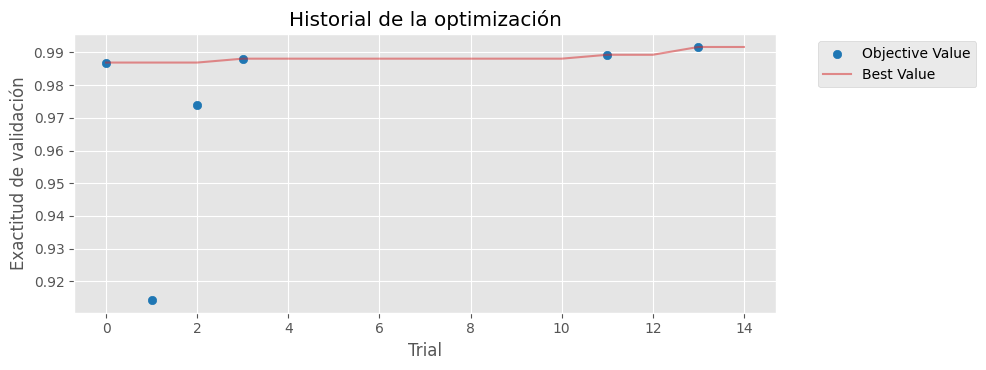

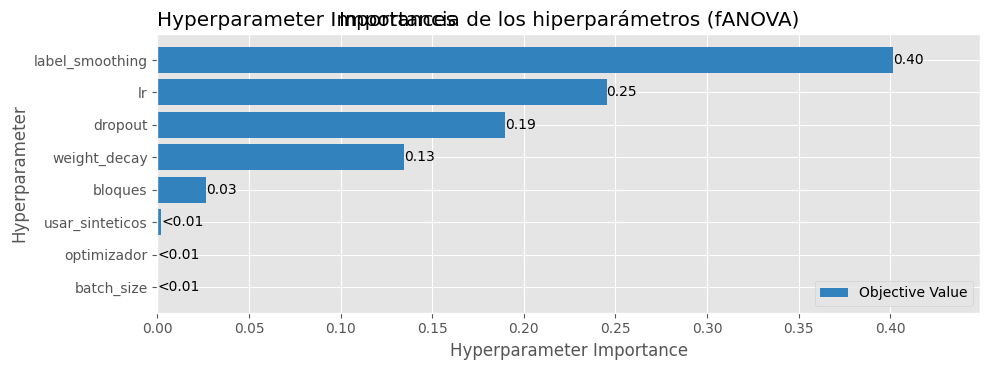

Mejor exactitud de validación (4 épocas): 0.9917
Mejores hiperparámetros:
  lr               = 0.000994261031688348
  weight_decay     = 0.0023772893664480432
  dropout          = 0.4118782604602264
  optimizador      = AdamW
  batch_size       = 32
  bloques          = 4
  label_smoothing  = 0.18886707473009462
  usar_sinteticos  = True


In [17]:
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances

ax = plot_optimization_history(estudio); ax.set_title('Historial de la optimización'); ax.set_ylabel('Exactitud de validación')
plt.gcf().set_size_inches(10, 3.8); plt.tight_layout(); plt.show()

ax = plot_param_importances(estudio); ax.set_title('Importancia de los hiperparámetros (fANOVA)')
plt.gcf().set_size_inches(10, 3.8); plt.tight_layout(); plt.show()

print('Mejor exactitud de validación (4 épocas):', round(estudio.best_value, 4))
print('Mejores hiperparámetros:')
for k, v in estudio.best_params.items():
    print(f'  {k:16s} = {v}')

## 7. Entrenamiento final con los mejores hiperparámetros

Con la mejor configuración encontrada por Optuna se entrena el modelo definitivo durante más épocas (20, con *early stopping* de paciencia 5).

Para medir el aporte real de la GAN se hace además un **estudio de ablación**: se entrena la misma configuración **con y sin** las imágenes sintéticas, cambiando únicamente esa variable. El modelo final es el de mayor exactitud de **validación**; el conjunto de prueba no interviene en la selección.

In [18]:
mejores = dict(estudio.best_params)
usar_sint_optuna = mejores.pop('usar_sinteticos')
cfg_final = dict(mejores)

modelo_sin_gan, hist_sin_gan = obtener_modelo('C_optuna_sin_gan', cfg_final, ds_train, ds_val, epocas=20, paciencia=5)
resultados['C. Optuna (sin GAN)'] = modelo_sin_gan

Época  1/20 | loss 0.9963 | acc 0.7211 | val_loss 0.3319 | val_acc 0.9393 | 20 s
Época  2/20 | loss 0.6897 | acc 0.9358 | val_loss 0.2130 | val_acc 0.9690 | 19 s
Época  3/20 | loss 0.6521 | acc 0.9586 | val_loss 0.2072 | val_acc 0.9786 | 20 s
Época  4/20 | loss 0.6269 | acc 0.9677 | val_loss 0.2143 | val_acc 0.9655 | 20 s
Época  5/20 | loss 0.6069 | acc 0.9802 | val_loss 0.2128 | val_acc 0.9810 | 20 s
Época  6/20 | loss 0.5964 | acc 0.9854 | val_loss 0.1865 | val_acc 0.9940 | 20 s
Época  7/20 | loss 0.5927 | acc 0.9882 | val_loss 0.1593 | val_acc 0.9929 | 20 s
Época  8/20 | loss 0.5881 | acc 0.9894 | val_loss 0.1656 | val_acc 0.9917 | 20 s
Época  9/20 | loss 0.5876 | acc 0.9899 | val_loss 0.1737 | val_acc 0.9917 | 20 s
Época 10/20 | loss 0.5808 | acc 0.9920 | val_loss 0.1727 | val_acc 0.9905 | 20 s
Época 11/20 | loss 0.5768 | acc 0.9949 | val_loss 0.1644 | val_acc 0.9940 | 20 s
Early stopping en la época 11
C_optuna_sin_gan: entrenado en 3.6 min


In [19]:
modelo_con_gan, hist_con_gan = obtener_modelo('D_optuna_con_gan', cfg_final, ds_train_gan, ds_val, epocas=20, paciencia=5)
resultados['D. Optuna + datos cDCGAN'] = modelo_con_gan

Época  1/20 | loss 0.9606 | acc 0.7503 | val_loss 0.3500 | val_acc 0.9167 | 25 s
Época  2/20 | loss 0.6713 | acc 0.9474 | val_loss 0.1932 | val_acc 0.9786 | 24 s
Época  3/20 | loss 0.6408 | acc 0.9630 | val_loss 0.1839 | val_acc 0.9845 | 25 s
Época  4/20 | loss 0.6202 | acc 0.9736 | val_loss 0.2185 | val_acc 0.9810 | 25 s
Época  5/20 | loss 0.6034 | acc 0.9835 | val_loss 0.1680 | val_acc 0.9881 | 25 s
Época  6/20 | loss 0.5934 | acc 0.9877 | val_loss 0.1984 | val_acc 0.9845 | 25 s
Época  7/20 | loss 0.5875 | acc 0.9898 | val_loss 0.1959 | val_acc 0.9869 | 25 s
Época  8/20 | loss 0.5855 | acc 0.9908 | val_loss 0.1743 | val_acc 0.9940 | 24 s
Época  9/20 | loss 0.5826 | acc 0.9916 | val_loss 0.1858 | val_acc 0.9917 | 25 s
Época 10/20 | loss 0.5782 | acc 0.9945 | val_loss 0.1763 | val_acc 0.9952 | 25 s
Época 11/20 | loss 0.5764 | acc 0.9948 | val_loss 0.1769 | val_acc 0.9940 | 25 s
Época 12/20 | loss 0.5716 | acc 0.9970 | val_loss 0.1706 | val_acc 0.9929 | 27 s
Época 13/20 | loss 0.5719 | 

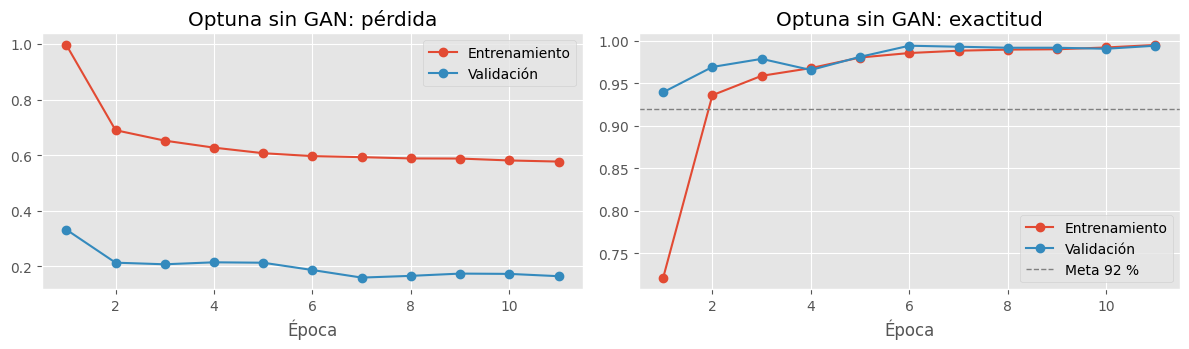

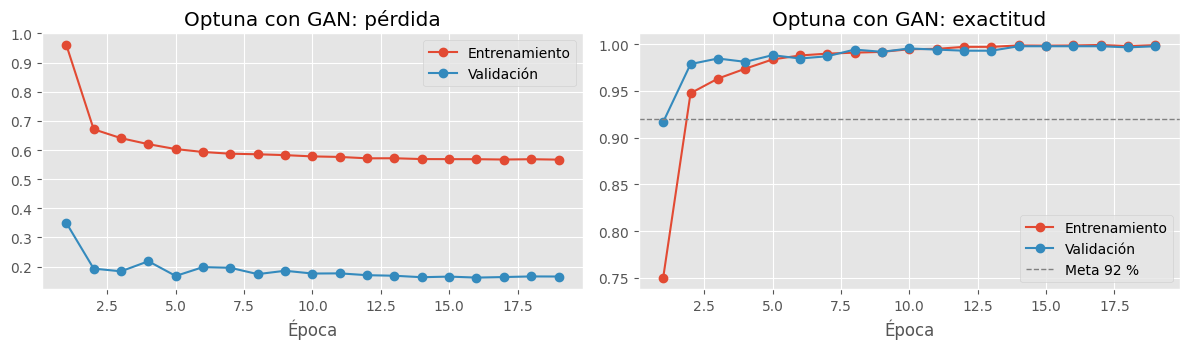

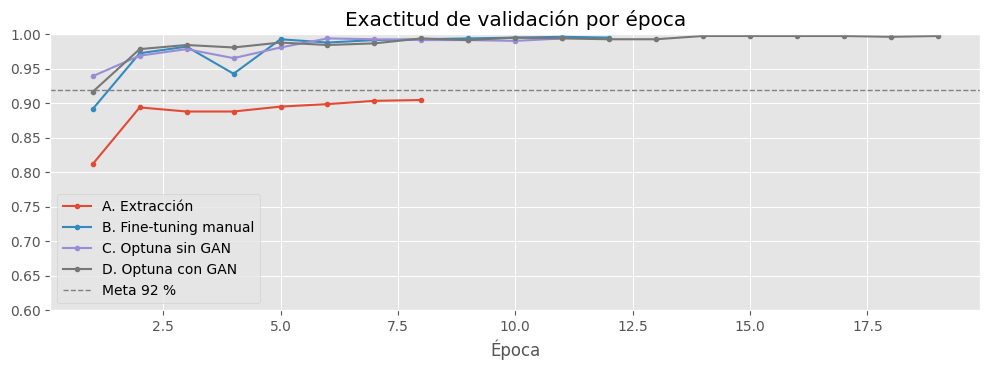

Validación sin GAN: 0.9940 | con GAN: 0.9976
Modelo final seleccionado (por validación): D. Optuna + datos cDCGAN


In [20]:
graficar_historial(hist_sin_gan, 'Optuna sin GAN')
graficar_historial(hist_con_gan, 'Optuna con GAN')

fig, ax = plt.subplots(figsize=(10, 3.8))
for nombre, h in [('A. Extracción', hist_fe), ('B. Fine-tuning manual', hist_ft),
                  ('C. Optuna sin GAN', hist_sin_gan), ('D. Optuna con GAN', hist_con_gan)]:
    ax.plot(range(1, len(h['val_acc']) + 1), h['val_acc'], 'o-', ms=3, label=nombre)
ax.axhline(0.92, color='gray', ls='--', lw=1, label='Meta 92 %')
ax.set_title('Exactitud de validación por época'); ax.set_xlabel('Época'); ax.set_ylim(0.6, 1.0); ax.legend()
plt.tight_layout(); plt.savefig(DIR_FIG / 'comparacion_val.png', dpi=120); plt.show()

val_sin, val_con = max(hist_sin_gan['val_acc']), max(hist_con_gan['val_acc'])
nombre_final = 'D. Optuna + datos cDCGAN' if val_con > val_sin else 'C. Optuna (sin GAN)'
modelo_final = resultados[nombre_final]
torch.save(modelo_final.state_dict(), DIR_MODELOS / 'clasificador_final.pt')
print(f'Validación sin GAN: {val_sin:.4f} | con GAN: {val_con:.4f}')
print('Modelo final seleccionado (por validación):', nombre_final)

## 8. Evaluación en el conjunto de prueba

Todos los modelos se evalúan sobre las **1,600 imágenes del conjunto `Testing`**, que no se usaron en ninguna etapa de entrenamiento ni de selección.

### 8.1 Comparación de los experimentos

In [21]:
filas, preds = [], {}
for nombre, m in resultados.items():
    yt, pt = predecir(m, ds_test)
    preds[nombre] = pt
    yhat = pt.argmax(1)
    filas.append({'Experimento': nombre,
                  'Exactitud': accuracy_score(yt, yhat),
                  'F1 macro': f1_score(yt, yhat, average='macro'),
                  'Errores': int((yhat != yt).sum())})
tabla = pd.DataFrame(filas).set_index('Experimento')
tabla.assign(Exactitud=tabla['Exactitud'].map('{:.2%}'.format), **{'F1 macro': tabla['F1 macro'].round(4)})

,Exactitud,F1 macro,Errores
Experimento,,,
A. Extracción de características,85.38%,0.8500,234
B. Fine-tuning manual,95.69%,0.9560,69
C. Optuna (sin GAN),95.44%,0.9535,73
D. Optuna + datos cDCGAN,95.50%,0.9541,72


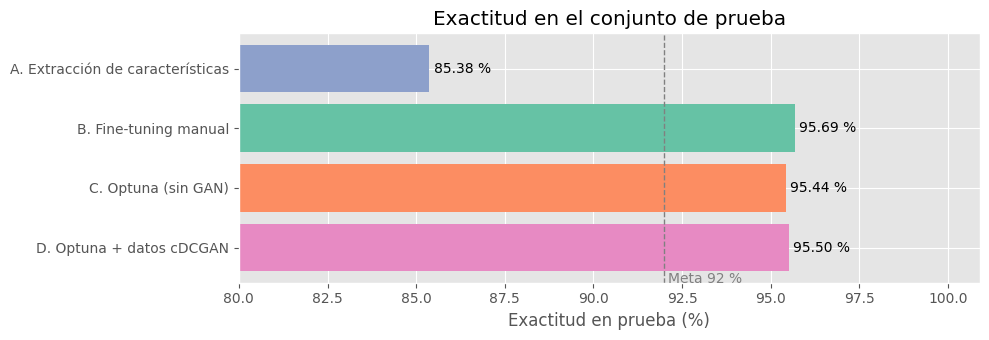

In [22]:
fig, ax = plt.subplots(figsize=(10, 3.5))
barras = ax.barh(tabla.index[::-1], tabla['Exactitud'][::-1] * 100, color=['#8DA0CB', '#66C2A5', '#FC8D62', '#E78AC3'][::-1])
ax.bar_label(barras, fmt='%.2f %%', padding=3)
ax.axvline(92, color='gray', ls='--', lw=1); ax.text(92.1, -0.6, 'Meta 92 %', color='gray')
ax.set_xlim(80, 100.9); ax.set_xlabel('Exactitud en prueba (%)'); ax.set_title('Exactitud en el conjunto de prueba')
plt.tight_layout(); plt.savefig(DIR_FIG / 'comparacion_test.png', dpi=120); plt.show()

### 8.2 Métricas detalladas del modelo final

In [23]:
y_true = y_test.numpy()
p_final = preds[nombre_final]
y_pred = p_final.argmax(1)
print(f'Modelo final: {nombre_final}')
print(f'Exactitud en prueba: {accuracy_score(y_true, y_pred):.2%}\n')
print(classification_report(y_true, y_pred, target_names=ETIQUETAS, digits=4))

Modelo final: D. Optuna + datos cDCGAN
Exactitud en prueba: 95.50%

              precision    recall  f1-score   support

      Glioma     0.9970    0.8375    0.9103       400
  Meningioma     0.9182    0.9825    0.9493       400
   Sin tumor     0.9217    1.0000    0.9592       400
  Pituitario     0.9950    1.0000    0.9975       400

    accuracy                         0.9550      1600
   macro avg     0.9580    0.9550    0.9541      1600
weighted avg     0.9580    0.9550    0.9541      1600



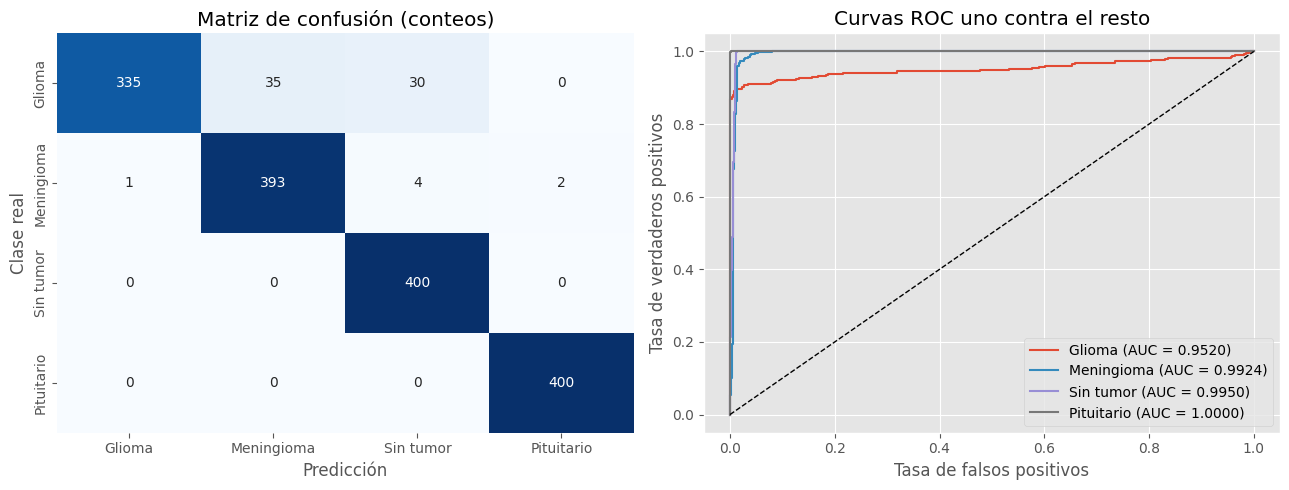

In [24]:
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=ETIQUETAS, yticklabels=ETIQUETAS, ax=ax[0], cbar=False)
ax[0].set_title('Matriz de confusión (conteos)'); ax[0].set_xlabel('Predicción'); ax[0].set_ylabel('Clase real')

y_bin = label_binarize(y_true, classes=range(N_CLASES))
for i in range(N_CLASES):
    fpr, tpr, _ = roc_curve(y_bin[:, i], p_final[:, i])
    ax[1].plot(fpr, tpr, label=f'{ETIQUETAS[i]} (AUC = {auc(fpr, tpr):.4f})')
ax[1].plot([0, 1], [0, 1], 'k--', lw=1)
ax[1].set_title('Curvas ROC uno contra el resto'); ax[1].set_xlabel('Tasa de falsos positivos')
ax[1].set_ylabel('Tasa de verdaderos positivos'); ax[1].legend(loc='lower right')
plt.tight_layout(); plt.savefig(DIR_FIG / 'matriz_roc.png', dpi=120); plt.show()

### 8.3 Interpretabilidad con Grad-CAM

En una aplicación médica no basta con que el modelo acierte: es importante verificar **en qué se fija**. Grad-CAM (Selvaraju et al., 2017) pondera los mapas de activación de la última capa convolucional con el gradiente de la clase predicha. El resultado es un mapa de calor de las regiones que más influyeron en la decisión.

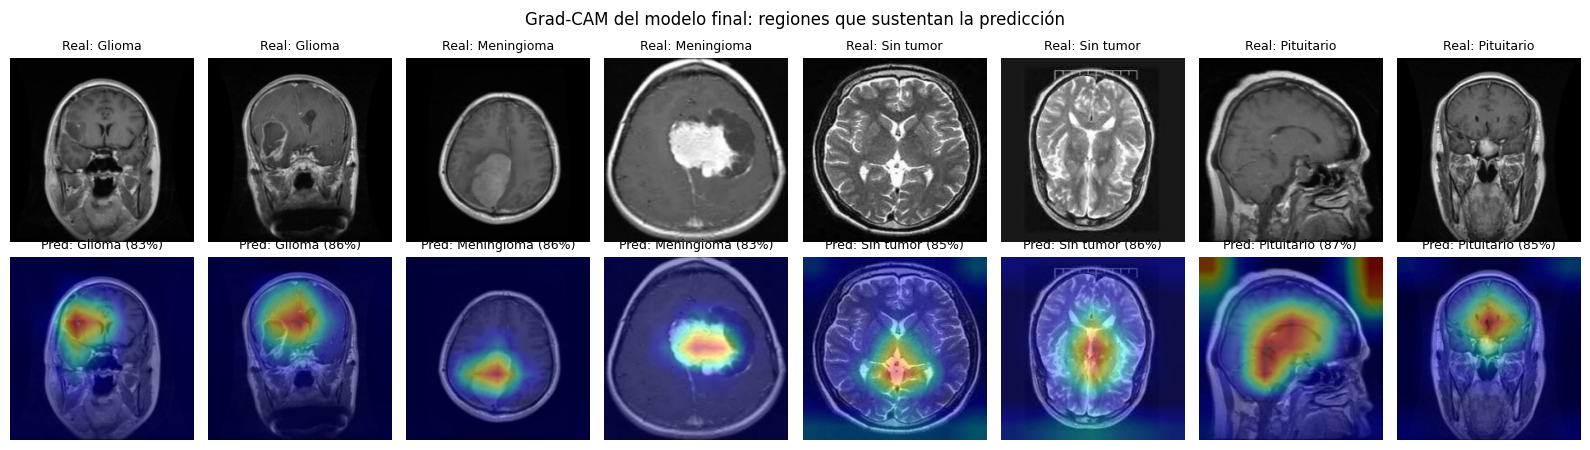

In [25]:
def grad_cam(m, x):
    m.eval(); guard = {}
    def hook(mod, inp, out):
        guard['a'] = out
        out.register_hook(lambda g: guard.__setitem__('g', g))
    h = m.features[-1].register_forward_hook(hook)
    out = m(x.unsqueeze(0).to(device))
    c = out.argmax(1).item()
    m.zero_grad(); out[0, c].backward(); h.remove()
    w = guard['g'].mean((2, 3), keepdim=True)
    cam = F.relu((w * guard['a']).sum(1, keepdim=True))
    cam = F.interpolate(cam, size=x.shape[-2:], mode='bilinear', align_corners=False)[0, 0]
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam.detach().cpu().numpy(), c, F.softmax(out, 1)[0, c].item()

for p in modelo_final.parameters():
    p.requires_grad_(True)
fig, axes = plt.subplots(2, 8, figsize=(16, 4.6))
rng = np.random.default_rng(SEED)
for i in range(N_CLASES):
    for j, k in enumerate(rng.choice(np.where(y_true == i)[0], 2, replace=False)):
        x, y = ds_test[k]
        cam, c, conf = grad_cam(modelo_final, x)
        col = 2 * i + j
        axes[0, col].imshow(desnormalizar(x), cmap='gray'); axes[0, col].axis('off')
        axes[0, col].set_title(f'Real: {ETIQUETAS[y]}', fontsize=9)
        axes[1, col].imshow(desnormalizar(x), cmap='gray'); axes[1, col].imshow(cam, cmap='jet', alpha=0.4)
        axes[1, col].set_title(f'Pred: {ETIQUETAS[c]} ({conf:.0%})', fontsize=9); axes[1, col].axis('off')
plt.suptitle('Grad-CAM del modelo final: regiones que sustentan la predicción')
plt.tight_layout(); plt.savefig(DIR_FIG / 'gradcam.png', dpi=120); plt.show()

### 8.4 Análisis de errores

Imágenes mal clasificadas: 72 de 1600
Glioma -> Meningioma        35
Glioma -> Sin tumor         30
Meningioma -> Sin tumor      4
Meningioma -> Pituitario     2
Meningioma -> Glioma         1


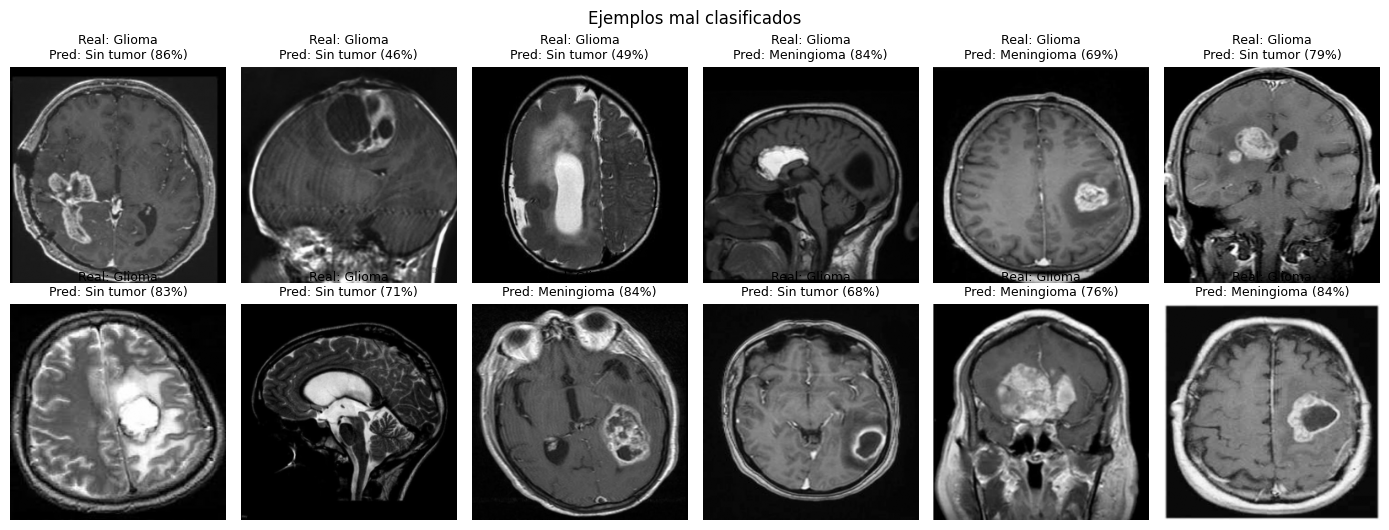

In [26]:
errores = np.where(y_pred != y_true)[0]
print(f'Imágenes mal clasificadas: {len(errores)} de {len(y_true)}')
pares = pd.Series([f'{ETIQUETAS[y_true[k]]} -> {ETIQUETAS[y_pred[k]]}' for k in errores]).value_counts()
print(pares.to_string())

n = min(len(errores), 12)
if n:
    fig, axes = plt.subplots(2, 6, figsize=(14, 5.4))
    for a in axes.flat: a.axis('off')
    for a, k in zip(axes.flat, errores[:n]):
        a.imshow(X_test[k, 0], cmap='gray')
        a.set_title(f'Real: {ETIQUETAS[y_true[k]]}\nPred: {ETIQUETAS[y_pred[k]]} ({p_final[k].max():.0%})', fontsize=9)
    plt.suptitle('Ejemplos mal clasificados'); plt.tight_layout(); plt.show()

### 8.5 Calidad de las imágenes sintéticas

Como medida indirecta de la calidad de la GAN, se pasa el conjunto sintético por el **modelo C**, entrenado únicamente con imágenes reales, y se mide con qué frecuencia reconoce la clase solicitada al generador. Es una versión simplificada de la idea detrás del *Inception Score* y del *Classification Accuracy Score*: si las imágenes condicionadas conservan los rasgos de su clase, un clasificador entrenado con datos reales debería reconocerlas.

In [27]:
ys, ps = predecir(modelo_sin_gan, MRIDataset(X_sint, y_sint, tf_eval))
acc_sint = (ps.argmax(1) == ys).mean()
print(f'Exactitud del modelo C (solo datos reales) sobre las imágenes sintéticas: {acc_sint:.2%}')
print(pd.Series((ps.argmax(1) == ys), index=[ETIQUETAS[i] for i in ys]).groupby(level=0).mean()
      .rename('Reconocidas como su clase').map('{:.1%}'.format).to_string())

Exactitud del modelo C (solo datos reales) sobre las imágenes sintéticas: 25.00%
Glioma          0.0%
Meningioma      0.0%
Pituitario      0.0%
Sin tumor     100.0%


## 9. Análisis de resultados y discusión

### 9.1 Resumen de los experimentos

| Experimento | Val. (mejor época) | Prueba | F1 macro | Errores en prueba |
|:--|:--:|:--:|:--:|:--:|
| A. Extracción de características | 90.48 % | 85.38 % | 0.8500 | 234 |
| B. Fine-tuning manual | 99.64 % | **95.69 %** | **0.9560** | 69 |
| C. Optuna (sin GAN) | 99.40 % | 95.44 % | 0.9535 | 73 |
| D. Optuna + datos cDCGAN (final) | **99.76 %** | 95.50 % | 0.9541 | 72 |

**Los cuatro modelos con fine-tuning superan la meta del 92 % en el conjunto de prueba**, que nunca se usó para entrenar ni para seleccionar. El modelo final, elegido por su exactitud de validación, alcanza **95.50 % de exactitud** y un F1 macro de 0.954.

### 9.2 Aporte del transfer learning

- **La extracción de características no basta.** Con el backbone congelado se llega a 90.5 % en validación y 85.4 % en prueba. Los filtros aprendidos en ImageNet (objetos y texturas naturales) son un buen punto de partida, pero no capturan los rasgos finos que distinguen un glioma de un meningioma en una resonancia magnética.
- **El fine-tuning es el factor decisivo.** Al descongelar el backbone, la exactitud en prueba sube más de 10 puntos (de 85.4 % a cerca de 95.5 %) y los errores bajan de 234 a unos 70. La red conserva el conocimiento general de ImageNet y adapta sus capas profundas al dominio médico.
- **El preentrenamiento acelera la convergencia.** El modelo B supera el 97 % de validación desde la segunda época. Entrenar una CNN desde cero con solo 4,760 imágenes requeriría muchas más épocas y probablemente sobreajustaría.

### 9.3 Aporte de la optimización de hiperparámetros

- La búsqueda con Optuna evaluó 15 configuraciones en 19.6 minutos. El *MedianPruner* detuvo 9 de ellas antes de completar sus 4 épocas, lo que ahorró más de la mitad del tiempo de cómputo.
- **Hallazgos de la búsqueda:**
  - **AdamW domina claramente a SGD**: ninguna prueba con SGD superó 92.7 % de validación.
  - Las mejores configuraciones combinan un lr de 5e-4 a 1e-3, *dropout* alto (cerca de 0.4) y *label smoothing* (0.1 a 0.19), es decir, **regularización fuerte**.
  - No hace falta descongelar toda la red: la mejor prueba descongela solo los **últimos 4 bloques**, con menos parámetros entrenables.
- Con esta configuración, el modelo C alcanza en 11 épocas un desempeño equivalente al del modelo B en 12 épocas, entrenando menos parámetros. Cada época es además más rápida (unos 20 s contra 26 s).
- **Discusión honesta:** en prueba, los modelos B, C y D quedan prácticamente empatados (95.4 % a 95.7 %; la diferencia es de 1 a 4 imágenes de 1,600). La validación está casi saturada (más de 99 %): con 840 imágenes, una diferencia de 0.3 % equivale a 3 imágenes. Así, la búsqueda tenía poco margen para distinguir configuraciones buenas de excelentes. La optimización sí fue útil para **descartar** zonas malas del espacio (SGD, lr muy bajos, poca regularización) y para encontrar una configuración más eficiente. Su ganancia en exactitud final, en cambio, queda dentro del ruido estadístico.

### 9.4 Aporte de la GAN

- La cDCGAN aprendió la **estructura global** de un corte cerebral: contorno del cráneo, forma del cerebro, planos sagital y coronal. Sin embargo, presenta **colapso de modo parcial**: las muestras de una misma clase son muy parecidas entre sí.
- Las curvas de entrenamiento muestran que el **discriminador dominó** el juego: D(x) subió a 0.85 y D(G(z)) bajó a casi 0.03, mientras la pérdida del generador crecía de forma sostenida. Es un desbalance típico de la DCGAN cuando el discriminador aprende más rápido que el generador.
- La prueba de calidad lo confirma: el modelo C, entrenado solo con datos reales, clasifica **todas** las imágenes sintéticas como "Sin tumor" (25 % de coincidencia, equivalente al azar). A 64 x 64 píxeles, y después de reescalarlas a 224, las imágenes no conservan los rasgos de la lesión que definen cada clase.
- En consecuencia, el **aporte de los datos sintéticos fue marginal**. Optuna eligió `usar_sinteticos = True` y el modelo D obtuvo la mejor validación (99.76 % contra 99.40 %), pero en prueba la diferencia con el modelo C es de una sola imagen. Lo más probable es que las imágenes sintéticas funcionaran como una forma de **regularización por ruido**, no como información nueva sobre los tumores.
- **Lecciones:** para que una GAN aporte en imágenes médicas se necesitan arquitecturas y resoluciones mayores (por ejemplo, StyleGAN2-ADA o modelos de difusión a 256 x 256), técnicas de estabilización (*spectral normalization*, pérdida de Wasserstein con penalización de gradiente) y métricas de calidad como FID antes de mezclar los datos. Aun así, el diseño experimental de ablación, con la misma configuración con y sin datos sintéticos, permitió **medir** el efecto en lugar de suponerlo.

### 9.5 Análisis por clase y de errores

- **Pituitario** (F1 de 0.998) y **Sin tumor** (recall de 100 %) se clasifican casi perfectamente. Los adenomas hipofisarios tienen una ubicación anatómica muy característica (región selar), lo que facilita su detección.
- **Glioma es la clase difícil** y tiene el AUC más bajo (0.952 contra 0.992 o más en las demás). Su precisión es de 99.7 % (cuando el modelo dice "glioma", casi siempre acierta), pero su recall es de 83.75 %: 65 de los 72 errores son gliomas, confundidos con meningioma (35) o con "Sin tumor" (30).
  - La confusión **glioma-meningioma** es clínicamente esperable: ambos pueden ser masas hiperintensas con contraste, y en cortes aislados su ubicación (intra-axial o extra-axial) no siempre es evidente.
  - La confusión **glioma-sin tumor** es más preocupante, porque es un **falso negativo**. Ocurre sobre todo en gliomas pequeños o infiltrantes, sin un realce claro, y en cortes donde la lesión apenas aparece.
- **Brecha entre validación y prueba:** la exactitud baja de cerca de 99.5 % en validación a 95.5 % en prueba, y casi toda la caída se concentra en gliomas. La validación se extrajo de la misma partición `Training`, mientras que el dataset combina tres fuentes (Figshare, SARTAJ y Br35H). Esto sugiere un **cambio de distribución** entre las particiones oficiales, y por eso la exactitud de validación sobreestima el desempeño real.
- **Grad-CAM** muestra que, en los casos con tumor, el modelo concentra su atención en la **región de la lesión**, y en los casos sin tumor en el centro del parénquima. Esto indica que la decisión se basa en rasgos anatómicamente relevantes y no en artefactos como bordes, texto o marcas del equipo.
- La confianza de las predicciones ronda el 85 % aun en aciertos claros. Es un efecto esperado del *label smoothing* de 0.19 elegido por Optuna, que evita salidas sobreconfiadas, una propiedad deseable en un sistema de apoyo clínico.

### 9.6 Limitaciones

- Se clasifican **cortes 2D aislados**; un radiólogo analiza el volumen completo y varias secuencias (T1, T2, FLAIR).
- El dataset proviene de fuentes públicas sin metadatos clínicos y no incluye otras patologías (metástasis, abscesos, ictus) que podrían confundirse con tumores.
- No hay validación externa en datos de otro hospital ni evaluación prospectiva con especialistas.
- El recall de glioma (83.75 %) es insuficiente para usar el sistema como filtro de descarte sin supervisión.

## 10. Pertinencia y utilidad de la solución

- **Apoyo al diagnóstico, no reemplazo.** Con 95.5 % de exactitud, AUC de 0.992 a 1.000 en meningioma, sin tumor y pituitario (0.952 en glioma) y mapas Grad-CAM que señalan la lesión, el clasificador es pertinente como **herramienta de apoyo**:
  - **Triaje:** prioriza en la lista de trabajo los estudios con sospecha de tumor.
  - **Segunda opinión:** sugiere el tipo de tumor más probable y la región que motivó la predicción.
- **Utilidad en contextos con pocos especialistas.** En hospitales de segundo nivel o regiones sin neurorradiólogo, una herramienta así puede acelerar la referencia de pacientes a centros especializados.
- **Bajo costo computacional.** EfficientNet-B0 tiene solo 5.3 M de parámetros (unos 16 MB en disco) y clasifica una imagen en milisegundos en una GPU portátil. Puede integrarse a un visor DICOM o ejecutarse en equipos modestos.
- **Transparencia.** La explicación visual con Grad-CAM y las probabilidades calibradas por el *label smoothing* permiten que el médico evalúe cuándo confiar en el modelo.
- **Uso responsable.** Por las limitaciones descritas (en particular el recall de glioma), antes de un uso clínico real el sistema requeriría:
  - Validación externa multicéntrica.
  - Ajuste del umbral de decisión para minimizar falsos negativos.
  - Aprobación regulatoria como software de dispositivo médico (en México, por COFEPRIS).

## 11. Conclusiones

1. Se diseñó e implementó un clasificador de resonancias magnéticas cerebrales en cuatro clases que alcanza **95.50 % de exactitud** en un conjunto de prueba independiente de 1,600 imágenes, **por encima de la meta del 92 %**.
2. El **transfer learning con fine-tuning** fue la técnica de mayor impacto: pasar de un backbone congelado a uno ajustado mejoró la exactitud en prueba en más de 10 puntos.
3. La **optimización bayesiana con Optuna** identificó automáticamente una configuración eficiente y bien regularizada (AdamW, lr cercano a 1e-3, 4 bloques descongelados, *dropout* de 0.41, *label smoothing* de 0.19). El *pruning* redujo a la mitad el costo de la búsqueda. Su mejora en exactitud final respecto a una configuración manual razonable quedó dentro del ruido, porque la validación ya estaba casi saturada.
4. La **cDCGAN** generó imágenes con la estructura general de un cerebro, pero con colapso de modo y sin rasgos tumorales discriminativos. Su aporte al clasificador fue marginal. La ablación lo hizo evidente y deja claro qué mejorar: mayor resolución, arquitecturas más estables y métricas de calidad previas.
5. El **análisis de errores** y **Grad-CAM** muestran que el modelo se enfoca en la lesión y que su principal debilidad es el recall de glioma. Esto orienta el trabajo futuro: más datos de gliomas difíciles, ajuste de umbrales para reducir falsos negativos, modelos 3D o multisecuencia y validación externa.

En conjunto, la práctica muestra cómo las técnicas del curso se complementan: el transfer learning aporta la capacidad de representación, la optimización de hiperparámetros la ajusta de forma sistemática y la GAN, bien entrenada, puede ampliar los datos. Un diseño experimental cuidadoso permite medir el aporte real de cada una.

## Referencias

- Nickparvar, M. (2021). *Brain Tumor MRI Dataset*. Kaggle. https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
- Tan, M., y Le, Q. (2019). EfficientNet: Rethinking Model Scaling for Convolutional Neural Networks. *ICML*.
- Radford, A., Metz, L., y Chintala, S. (2015). Unsupervised Representation Learning with Deep Convolutional Generative Adversarial Networks. *arXiv:1511.06434*.
- Mirza, M., y Osindero, S. (2014). Conditional Generative Adversarial Nets. *arXiv:1411.1784*.
- Akiba, T., Sano, S., Yanase, T., Ohta, T., y Koyama, M. (2019). Optuna: A Next-generation Hyperparameter Optimization Framework. *KDD*.
- Selvaraju, R. R. et al. (2017). Grad-CAM: Visual Explanations from Deep Networks via Gradient-based Localization. *ICCV*.
- Bergstra, J., Bardenet, R., Bengio, Y., y Kégl, B. (2011). Algorithms for Hyper-Parameter Optimization. *NeurIPS*.
- Hernández Parada, M. S. (2026). *Práctica 4.1: Diseño y desarrollo de un clasificador* [Notebook de Jupyter]. GitHub. <https://github.com/RKCbas/LENGUAJES-DE-CIENCIA-DE-DATOS-B-SICO---PRACTICAS/blob/main/Cuatrimestre%204/8%20-%20Aprendizaje%20profundo/Practica%204.1/Dise%C3%B1o%20y%20desarrollo%20de%20un%20clasificador.ipynb>